In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# 2019
zip_2019 = "/content/drive/MyDrive/MLPR/MIMII Dataset/2019/6_dB_pump.zip"
extract_2019 = "/content/mimii_2019"
os.makedirs(extract_2019, exist_ok=True)

with zipfile.ZipFile(zip_2019, 'r') as zip_ref:
    zip_ref.extractall(extract_2019)

# 2021
zip_2021 = "/content/drive/MyDrive/MLPR/MIMII Dataset/2021/dev_data_pump.zip"
extract_2021 = "/content/mimii_2021"
os.makedirs(extract_2021, exist_ok=True)

with zipfile.ZipFile(zip_2021, 'r') as zip_ref:
    zip_ref.extractall(extract_2021)

Mounted at /content/drive


In [5]:
for root, dirs, files in os.walk(extract_2019):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*60)

ROOT: /content/mimii_2019
DIRS: ['pump']
FILES: []
------------------------------------------------------------
ROOT: /content/mimii_2019/pump
DIRS: ['id_06', 'id_00', 'id_02', 'id_04']
FILES: []
------------------------------------------------------------
ROOT: /content/mimii_2019/pump/id_06
DIRS: ['normal', 'abnormal']
FILES: []
------------------------------------------------------------
ROOT: /content/mimii_2019/pump/id_06/normal
DIRS: []
FILES: ['00000428.wav', '00000859.wav', '00000340.wav', '00000173.wav', '00000102.wav']
------------------------------------------------------------
ROOT: /content/mimii_2019/pump/id_06/abnormal
DIRS: []
FILES: ['00000077.wav', '00000040.wav', '00000022.wav', '00000004.wav', '00000075.wav']
------------------------------------------------------------
ROOT: /content/mimii_2019/pump/id_00
DIRS: ['normal', 'abnormal']
FILES: []
------------------------------------------------------------
ROOT: /content/mimii_2019/pump/id_00/normal
DIRS: []
FILES: ['0

In [6]:
!pip install librosa

In [7]:
import librosa
import numpy as np
import pandas as pd
import os

### 2019

In [8]:
def extract_features(file_path, n_mfcc=40):

    audio, sample_rate = librosa.load(file_path, sr=None)

    mfccs = librosa.feature.mfcc(
        y=audio,
        sr=sample_rate,
        n_mfcc=n_mfcc
    )

    mfccs_scaled = np.mean(mfccs.T, axis=0)

    return mfccs_scaled

In [9]:
X_2019 = []
y_2019 = []

base_path_2019 = "/content/mimii_2019/pump"

for machine_id in os.listdir(base_path_2019):

    machine_path = os.path.join(base_path_2019, machine_id)

    if not os.path.isdir(machine_path):
        continue

    for label_folder in ['normal', 'abnormal']:

        folder_path = os.path.join(machine_path, label_folder)

        label = 0 if label_folder == 'normal' else 1

        for file_name in os.listdir(folder_path):

            if file_name.endswith('.wav'):

                file_path = os.path.join(folder_path, file_name)

                try:
                    features = extract_features(file_path)

                    X_2019.append(features)
                    y_2019.append(label)

                except Exception as e:
                    print("Error processing:", file_path)
                    print(e)

In [10]:
X_2019 = np.array(X_2019)
y_2019 = np.array(y_2019)

print(X_2019.shape)
print(y_2019.shape)

(4205, 40)
(4205,)


In [11]:
unique, counts = np.unique(y_2019, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 3749
Class 1: 456


In [12]:
print(X_2019[0])
print("Feature vector length:", len(X_2019[0]))

[-4.24507935e+02  1.16907021e+02  1.72294273e+01  7.49183655e+00
 -5.29207706e+00  1.49347270e+00 -3.33757544e+00 -1.67408788e+00
 -2.11592340e+00  6.16139531e-01 -1.72078907e+00 -4.43081951e+00
 -4.16298866e+00 -3.50723529e+00 -5.44513226e+00 -8.65775406e-01
  1.76068389e+00  3.31024885e+00 -2.13286114e+00 -5.76050138e+00
 -1.04810705e+01 -6.63368845e+00 -2.46574378e+00  2.62612969e-01
  2.11128330e+00  4.76537180e+00  6.90740776e+00  6.90999031e+00
  1.79058897e+00 -3.21747112e+00 -5.41353226e+00 -2.84196615e+00
  7.47318789e-02  1.13316762e+00  1.90268612e+00 -3.43638062e-01
 -3.83059144e+00 -4.27908897e+00 -4.10986328e+00  2.26739526e+00]
Feature vector length: 40


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_2019,
    y_2019,
    test_size=0.2,
    random_state=42,
    stratify=y_2019
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)

{0: np.float64(0.5608536178726242), 1: np.float64(4.608219178082192)}


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(40,)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9989 - loss: 0.0057 - val_accuracy: 0.9941 - val_loss: 0.0434
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9963 - loss: 0.0108 - val_accuracy: 0.9881 - val_loss: 0.0694
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9903 - loss: 0.0213 - val_accuracy: 0.9926 - val_loss: 0.0428
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9941 - loss: 0.0202 - val_accuracy: 0.9896 - val_loss: 0.0425
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9981 - loss: 0.0039 - val_accuracy: 0.9911 - val_loss: 0.0468


In [22]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC      :", auc)

Accuracy : 0.9976218787158145
Precision: 1.0
Recall   : 0.978021978021978
F1 Score : 0.9888888888888889
AUC      : 0.9867985347985349


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       750
           1       1.00      0.98      0.99        91

    accuracy                           1.00       841
   macro avg       1.00      0.99      0.99       841
weighted avg       1.00      1.00      1.00       841



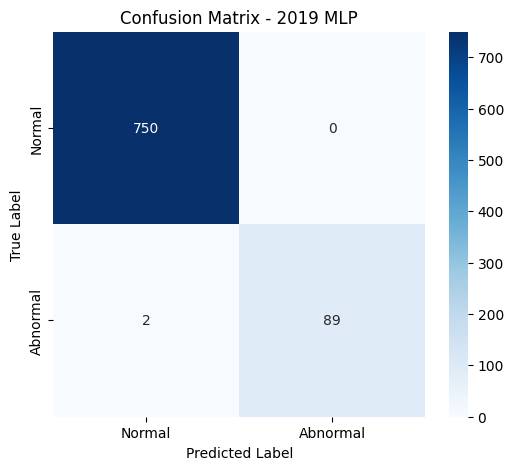

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - 2019 MLP")

plt.show()

In [26]:
model.save("mlp_2019_model.h5")

### 2021

In [28]:
for root, dirs, files in os.walk(extract_2021):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    print("-"*60)

ROOT: /content/mimii_2021
DIRS: ['pump']
FILES: []
------------------------------------------------------------
ROOT: /content/mimii_2021/pump
DIRS: ['target_test', 'train', 'source_test']
FILES: []
------------------------------------------------------------
ROOT: /content/mimii_2021/pump/target_test
DIRS: []
FILES: ['section_00_target_test_anomaly_0059.wav', 'section_00_target_test_anomaly_0034.wav', 'section_00_target_test_normal_0000.wav', 'section_01_target_test_anomaly_0055.wav', 'section_00_target_test_anomaly_0061.wav']
------------------------------------------------------------
ROOT: /content/mimii_2021/pump/train
DIRS: []
FILES: ['section_00_source_train_normal_0950_serial_no_000_water.wav', 'section_00_source_train_normal_0552_serial_no_000_water.wav', 'section_00_source_train_normal_0151_serial_no_000_water.wav', 'section_01_source_train_normal_0753_serial_no_010_water.wav', 'section_01_source_train_normal_0225_serial_no_010_water.wav']
------------------------------------

In [29]:
X_target = []
y_target = []

target_path = "/content/mimii_2021/pump/target_test"

for file_name in os.listdir(target_path):

    if file_name.endswith(".wav"):

        file_path = os.path.join(target_path, file_name)

        # Labels from filename
        if "normal" in file_name:
            label = 0
        elif "anomaly" in file_name:
            label = 1
        else:
            continue

        try:
            features = extract_features(file_path)

            X_target.append(features)
            y_target.append(label)

        except Exception as e:
            print("Error:", file_path)
            print(e)

In [30]:
X_target = np.array(X_target)
y_target = np.array(y_target)

print(X_target.shape)
print(y_target.shape)

(600, 40)
(600,)


In [31]:
unique, counts = np.unique(y_target, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 0: 300
Class 1: 300


In [32]:
X_target = scaler.transform(X_target)

In [33]:
y_target_prob = model.predict(X_target)

y_target_pred = (y_target_prob > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [34]:
accuracy_target = accuracy_score(y_target, y_target_pred)
precision_target = precision_score(y_target, y_target_pred)
recall_target = recall_score(y_target, y_target_pred)
f1_target = f1_score(y_target, y_target_pred)
auc_target = roc_auc_score(y_target, y_target_prob)

print("Target Accuracy :", accuracy_target)
print("Target Precision:", precision_target)
print("Target Recall   :", recall_target)
print("Target F1 Score :", f1_target)
print("Target AUC      :", auc_target)

Target Accuracy : 0.4816666666666667
Target Precision: 0.48525469168900803
Target Recall   : 0.6033333333333334
Target F1 Score : 0.537890044576523
Target AUC      : 0.4828388888888889


In [35]:
print(classification_report(y_target, y_target_pred))

              precision    recall  f1-score   support

           0       0.48      0.36      0.41       300
           1       0.49      0.60      0.54       300

    accuracy                           0.48       600
   macro avg       0.48      0.48      0.47       600
weighted avg       0.48      0.48      0.47       600



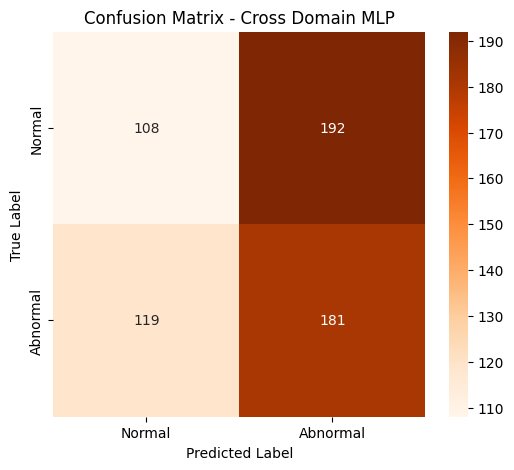

In [106]:
cm_target = confusion_matrix(y_target, y_target_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_target,
    annot=True,
    fmt='d',
    cmap='Oranges',   # changed color
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Cross Domain MLP")

plt.show()

### Transfer Learning

In [50]:
from tensorflow.keras.models import load_model
import tensorflow as tf

base_model = load_model("mlp_2019_model.h5")

In [51]:
adapt_model = tf.keras.models.clone_model(base_model)

adapt_model.set_weights(base_model.get_weights())

In [52]:
for layer in adapt_model.layers[:-1]:
    layer.trainable = False

In [53]:
adapt_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [54]:
history_adapt = adapt_model.fit(
    X_train_2021,
    y_train_2021,
    epochs=2,
    batch_size=32,
    verbose=1
)

Epoch 1/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4084 - loss: 4.3446
Epoch 2/2
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4035 - loss: 4.3500


In [55]:
y_adapt_prob = adapt_model.predict(X_target)

y_adapt_pred = (y_adapt_prob > 0.5).astype(int)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy_adapt = accuracy_score(y_target, y_adapt_pred)
precision_adapt = precision_score(y_target, y_adapt_pred)
recall_adapt = recall_score(y_target, y_adapt_pred)
f1_adapt = f1_score(y_target, y_adapt_pred)
auc_adapt = roc_auc_score(y_target, y_adapt_prob)

print("Adapt Accuracy :", accuracy_adapt)
print("Adapt Precision:", precision_adapt)
print("Adapt Recall   :", recall_adapt)
print("Adapt F1 Score :", f1_adapt)
print("Adapt AUC      :", auc_adapt)

Adapt Accuracy : 0.4816666666666667
Adapt Precision: 0.48525469168900803
Adapt Recall   : 0.6033333333333334
Adapt F1 Score : 0.537890044576523
Adapt AUC      : 0.4828222222222222


In [57]:
print(classification_report(y_target, y_adapt_pred))

              precision    recall  f1-score   support

           0       0.48      0.36      0.41       300
           1       0.49      0.60      0.54       300

    accuracy                           0.48       600
   macro avg       0.48      0.48      0.47       600
weighted avg       0.48      0.48      0.47       600



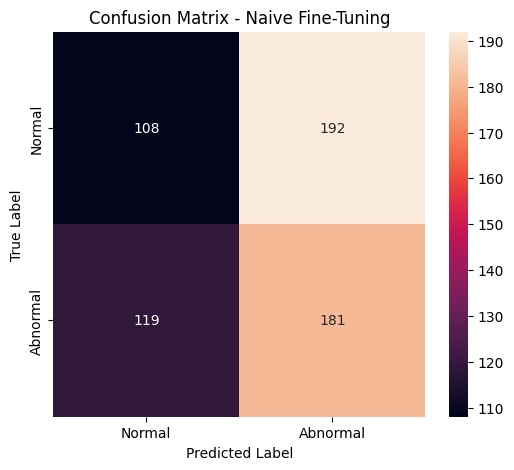

In [108]:
cm_adapt = confusion_matrix(y_target, y_adapt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_adapt,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naive Fine-Tuning")

plt.show()

### Auto Encoder

In [69]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_2021.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation='relu')(input_layer)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)

# Bottleneck
latent = Dense(16, activation='relu')(x)

# Decoder
x = Dense(32, activation='relu')(latent)

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(128, activation='relu')(x)

output_layer = Dense(input_dim, activation='linear')(x)

improved_ae = Model(inputs=input_layer, outputs=output_layer)

In [70]:
improved_ae.compile(
    optimizer='adam',
    loss='mse'
)

In [71]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [72]:
history_improved = improved_ae.fit(
    X_train_2021,
    X_train_2021,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.8774 - val_loss: 0.6005
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5481 - val_loss: 0.4124
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4283 - val_loss: 0.3437
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3710 - val_loss: 0.3142
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3507 - val_loss: 0.2945
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3254 - val_loss: 0.2747
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3081 - val_loss: 0.2759
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2946 - val_loss: 0.2403
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2840 - val_loss: 0.2340
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2739 - val_loss: 0.2247
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2611 - val_loss: 0.2292
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.

In [73]:
X_recon_improved = improved_ae.predict(X_target)

reconstruction_error_improved = np.mean(
    np.square(X_target - X_recon_improved),
    axis=1
)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [74]:
thresholds = [70, 75, 80, 85, 90]

for p in thresholds:

    threshold = np.percentile(reconstruction_error_improved, p)

    y_temp = (reconstruction_error_improved > threshold).astype(int)

    acc = accuracy_score(y_target, y_temp)
    prec = precision_score(y_target, y_temp)
    rec = recall_score(y_target, y_temp)
    f1 = f1_score(y_target, y_temp)

    print(f"\nPercentile: {p}")
    print("Threshold :", threshold)
    print("Accuracy  :", acc)
    print("Precision :", prec)
    print("Recall    :", rec)
    print("F1 Score  :", f1)


Percentile: 70
Threshold : 0.21174154
Accuracy  : 0.5366666666666666
Precision : 0.5611111111111111
Recall    : 0.33666666666666667
F1 Score  : 0.42083333333333334

Percentile: 75
Threshold : 0.23018754
Accuracy  : 0.5366666666666666
Precision : 0.5733333333333334
Recall    : 0.2866666666666667
F1 Score  : 0.38222222222222224

Percentile: 80
Threshold : 0.25967523
Accuracy  : 0.5433333333333333
Precision : 0.6083333333333333
Recall    : 0.24333333333333335
F1 Score  : 0.3476190476190476

Percentile: 85
Threshold : 0.31104234
Accuracy  : 0.53
Precision : 0.6
Recall    : 0.18
F1 Score  : 0.27692307692307694

Percentile: 90
Threshold : 0.3841429
Accuracy  : 0.5066666666666667
Precision : 0.5333333333333333
Recall    : 0.10666666666666667
F1 Score  : 0.17777777777777778


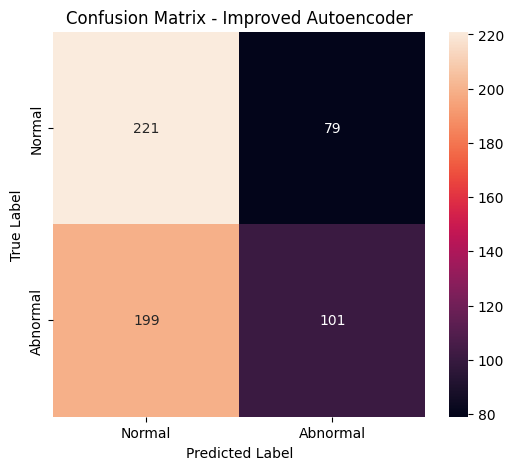

In [110]:
best_threshold = np.percentile(reconstruction_error_improved, 70)

y_best = (reconstruction_error_improved > best_threshold).astype(int)

cm_best = confusion_matrix(y_target, y_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Improved Autoencoder")

plt.show()

### Denoising Autoencoder

In [92]:
noise_factor = 0.1

X_train_noisy = X_train_2021 + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train_2021.shape
)

# Keep values stable
X_train_noisy = np.clip(X_train_noisy, -5, 5)

In [93]:
input_dim = X_train_2021.shape[1]

input_layer = Input(shape=(input_dim,))

# Encoder
x = Dense(128, activation='relu')(input_layer)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)

# Bottleneck
latent = Dense(16, activation='relu')(x)

# Decoder
x = Dense(32, activation='relu')(latent)

x = Dense(64, activation='relu')(x)

x = Dense(128, activation='relu')(x)

output_layer = Dense(input_dim, activation='linear')(x)

dae = Model(inputs=input_layer, outputs=output_layer)

In [94]:
dae.compile(
    optimizer='adam',
    loss='mse'
)

In [95]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [96]:
history_dae = dae.fit(
    X_train_noisy,
    X_train_2021,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.9117 - val_loss: 0.5846
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5055 - val_loss: 0.4304
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3832 - val_loss: 0.3341
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3229 - val_loss: 0.2921
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2977 - val_loss: 0.2707
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2761 - val_loss: 0.2555
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2585 - val_loss: 0.2394
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2431 - val_loss: 0.2245
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2362 - val_loss: 0.2218
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2267 - val_loss: 0.2157
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2212 - val_loss: 0.2110
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.

In [97]:
X_dae_recon = dae.predict(X_target)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [98]:
dae_error = np.mean(
    np.square(X_target - X_dae_recon),
    axis=1
)

In [99]:
thresholds = [50, 55, 60, 65, 70, 75, 80]

best_f1 = 0

for p in thresholds:

    threshold = np.percentile(dae_error, p)

    y_temp = (dae_error > threshold).astype(int)

    acc = accuracy_score(y_target, y_temp)
    prec = precision_score(y_target, y_temp)
    rec = recall_score(y_target, y_temp)
    f1 = f1_score(y_target, y_temp)

    print(f"\nPercentile: {p}")
    print("Accuracy  :", acc)
    print("Precision :", prec)
    print("Recall    :", rec)
    print("F1 Score  :", f1)

    if f1 > best_f1:
        best_f1 = f1
        best_acc = acc
        best_prec = prec
        best_rec = rec
        best_threshold = threshold


Percentile: 50
Accuracy  : 0.55
Precision : 0.55
Recall    : 0.55
F1 Score  : 0.55

Percentile: 55
Accuracy  : 0.5533333333333333
Precision : 0.5592592592592592
Recall    : 0.5033333333333333
F1 Score  : 0.5298245614035088

Percentile: 60
Accuracy  : 0.5566666666666666
Precision : 0.5708333333333333
Recall    : 0.45666666666666667
F1 Score  : 0.5074074074074074

Percentile: 65
Accuracy  : 0.5566666666666666
Precision : 0.580952380952381
Recall    : 0.4066666666666667
F1 Score  : 0.47843137254901963

Percentile: 70
Accuracy  : 0.5433333333333333
Precision : 0.5722222222222222
Recall    : 0.3433333333333333
F1 Score  : 0.42916666666666664

Percentile: 75
Accuracy  : 0.5366666666666666
Precision : 0.5733333333333334
Recall    : 0.2866666666666667
F1 Score  : 0.38222222222222224

Percentile: 80
Accuracy  : 0.5433333333333333
Precision : 0.6083333333333333
Recall    : 0.24333333333333335
F1 Score  : 0.3476190476190476


In [101]:
threshold = np.percentile(dae_error, 50)

y_final_pred = (dae_error > threshold).astype(int)

In [102]:
accuracy = accuracy_score(y_target, y_final_pred)
precision = precision_score(y_target, y_final_pred)
recall = recall_score(y_target, y_final_pred)
f1 = f1_score(y_target, y_final_pred)

print("Final Accuracy :", accuracy)
print("Final Precision:", precision)
print("Final Recall   :", recall)
print("Final F1 Score :", f1)

Final Accuracy : 0.55
Final Precision: 0.55
Final Recall   : 0.55
Final F1 Score : 0.55


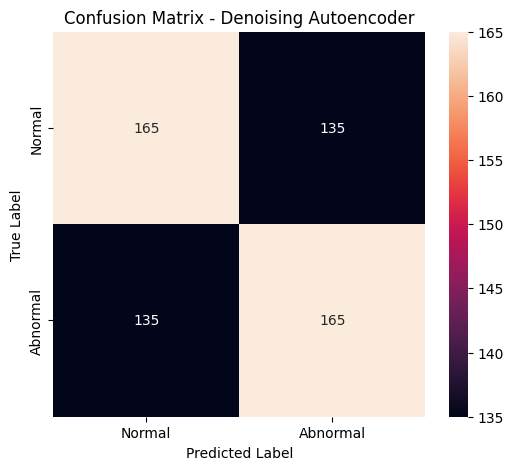

In [112]:
cm = confusion_matrix(y_target, y_final_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal', 'Abnormal'],
    yticklabels=['Normal', 'Abnormal']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Denoising Autoencoder")

plt.show()

In [104]:
print(classification_report(y_target, y_final_pred))

              precision    recall  f1-score   support

           0       0.55      0.55      0.55       300
           1       0.55      0.55      0.55       300

    accuracy                           0.55       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.55      0.55      0.55       600



In [116]:
import pandas as pd

final_results = pd.DataFrame({

    "Method": [
        "MLP on 2019",
        "Cross-Domain MLP",
        "Naive Fine-Tuning",
        "Improved Autoencoder",
        "Denoising Autoencoder"
    ],

    "Accuracy": [
        0.9976,
        0.4817,
        0.5000,
        0.5367,
        0.5500
    ],

    "Precision": [
        1.0000,
        0.4853,
        0.0000,
        0.5611,
        0.5500
    ],

    "Recall": [
        0.9780,
        0.6033,
        0.0000,
        0.3367,
        0.5500
    ],

    "F1 Score": [
        0.9889,
        0.5379,
        0.0000,
        0.4210,
        0.5500
    ]

})
final_results.index = range(1, len(final_results) + 1)

In [117]:
final_results.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Method,Accuracy,Precision,Recall,F1 Score
1,MLP on 2019,0.9976,1.0000,0.9780,0.9889
2,Cross-Domain MLP,0.4817,0.4853,0.6033,0.5379
3,Naive Fine-Tuning,0.5000,0.0000,0.0000,0.0000
4,Improved Autoencoder,0.5367,0.5611,0.3367,0.4210
5,Denoising Autoencoder,0.5500,0.5500,0.5500,0.5500
